# Projet 6 - Initiez-vous au MLOps (partie 1/2)


**Objectif du projet**  
Prédire la probabilité de défaut de paiement d'un client (TARGET = 1)  
→ Problème de **classification binaire déséquilibrée**

**Approche MLOps visée dans cette première partie**  
- Suivi systématique des expériences avec **MLflow**  
- Comparaison de plusieurs modèles / jeux de features  
- Versionning des modèles  



Date : Janvier 2026  
Auteur : Joannes Landy

## Étape 1 - Préparez, nettoyez et enrichissez les données

**Préparation des données**

**Objectif**  
Constituer un jeu de données propre, fusionné et enrichi à partir des différentes sources, prêt pour l'entraînement d'un modèle de scoring de crédit.

### Exploration des données bruts

Description des champs présents dans les données bruts.

Précision sur le type de donnée, les valeurs statistiques de base, min, max, moyenne, quantiles, valeurs null, valeurs identiques.

In [1]:
from pathlib import Path
import pandas as pd
import mlflow
import json
import logging
import os


import logging
logger = logging.getLogger(__name__)


# configuration des paramètres de connexion et des répertoires de travail
MLFLOW_URL = "http://localhost:5000"
DATA_DIR = str(Path.home() / "data")
EXPERIMENT_NAME = "Projet 06 - OpenClassrooms v4"




In [2]:
# Importations
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns



# Chargement des fichiers du repertoire data_path, création des dataframes

def csv_to_dataframe(data_path):
    """ list csv files in data_path and return dic with all dataframes """
    dataframes = {}
    files = list(Path(data_path).glob("*.csv"))
    
    for file in files:
    
        dataframe_name = file.name.replace(".csv", "")
        df = pd.read_csv(os.path.join(data_path, file.name))
        dataframes[dataframe_name] = df

    print('dataframe:', dataframes.keys())
    return dataframes
    
print("répertoire: ", DATA_DIR + '/raw')
df_brut = csv_to_dataframe(DATA_DIR + '/raw')
      



répertoire:  /home/joannes/data/raw
dataframe: dict_keys(['bureau_balance', 'credit_card_balance', 'bureau', 'previous_application', 'application_train', 'installments_payments', 'POS_CASH_balance'])


Voici les clés d'index pour chaque fichier CSV :
| Fichier CSV | Clé(s) d'index | Tables liées |
|------------|----------------|-------------|
| application_train | SK_ID_CURR | bureau.csv, previous_application.csv, installments_payments.csv, POS_CASH_balance.csv, credit_card_balance.csv |
| application_test | SK_ID_CURR | bureau.csv, previous_application.csv, installments_payments.csv, POS_CASH_balance.csv, credit_card_balance.csv |
| bureau | SK_ID_BUREAU | int64 |bureau_balance.csv|
| previous_application | SK_ID_PREV | credit_card_balance.csv, POS_CASH_balance.csv, installments_payments.csv |




### Analyse de la distribution des données bruts

Visualisation des histogrammes

Recherche des outliers

Fichier:  bureau_balance


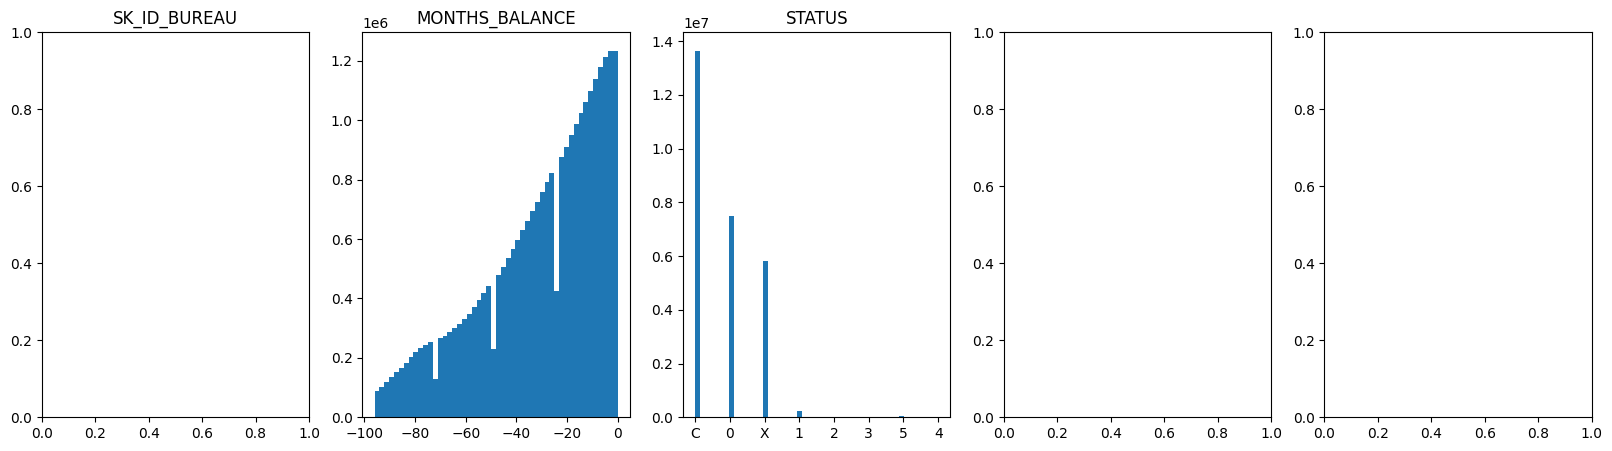

Fichier:  credit_card_balance


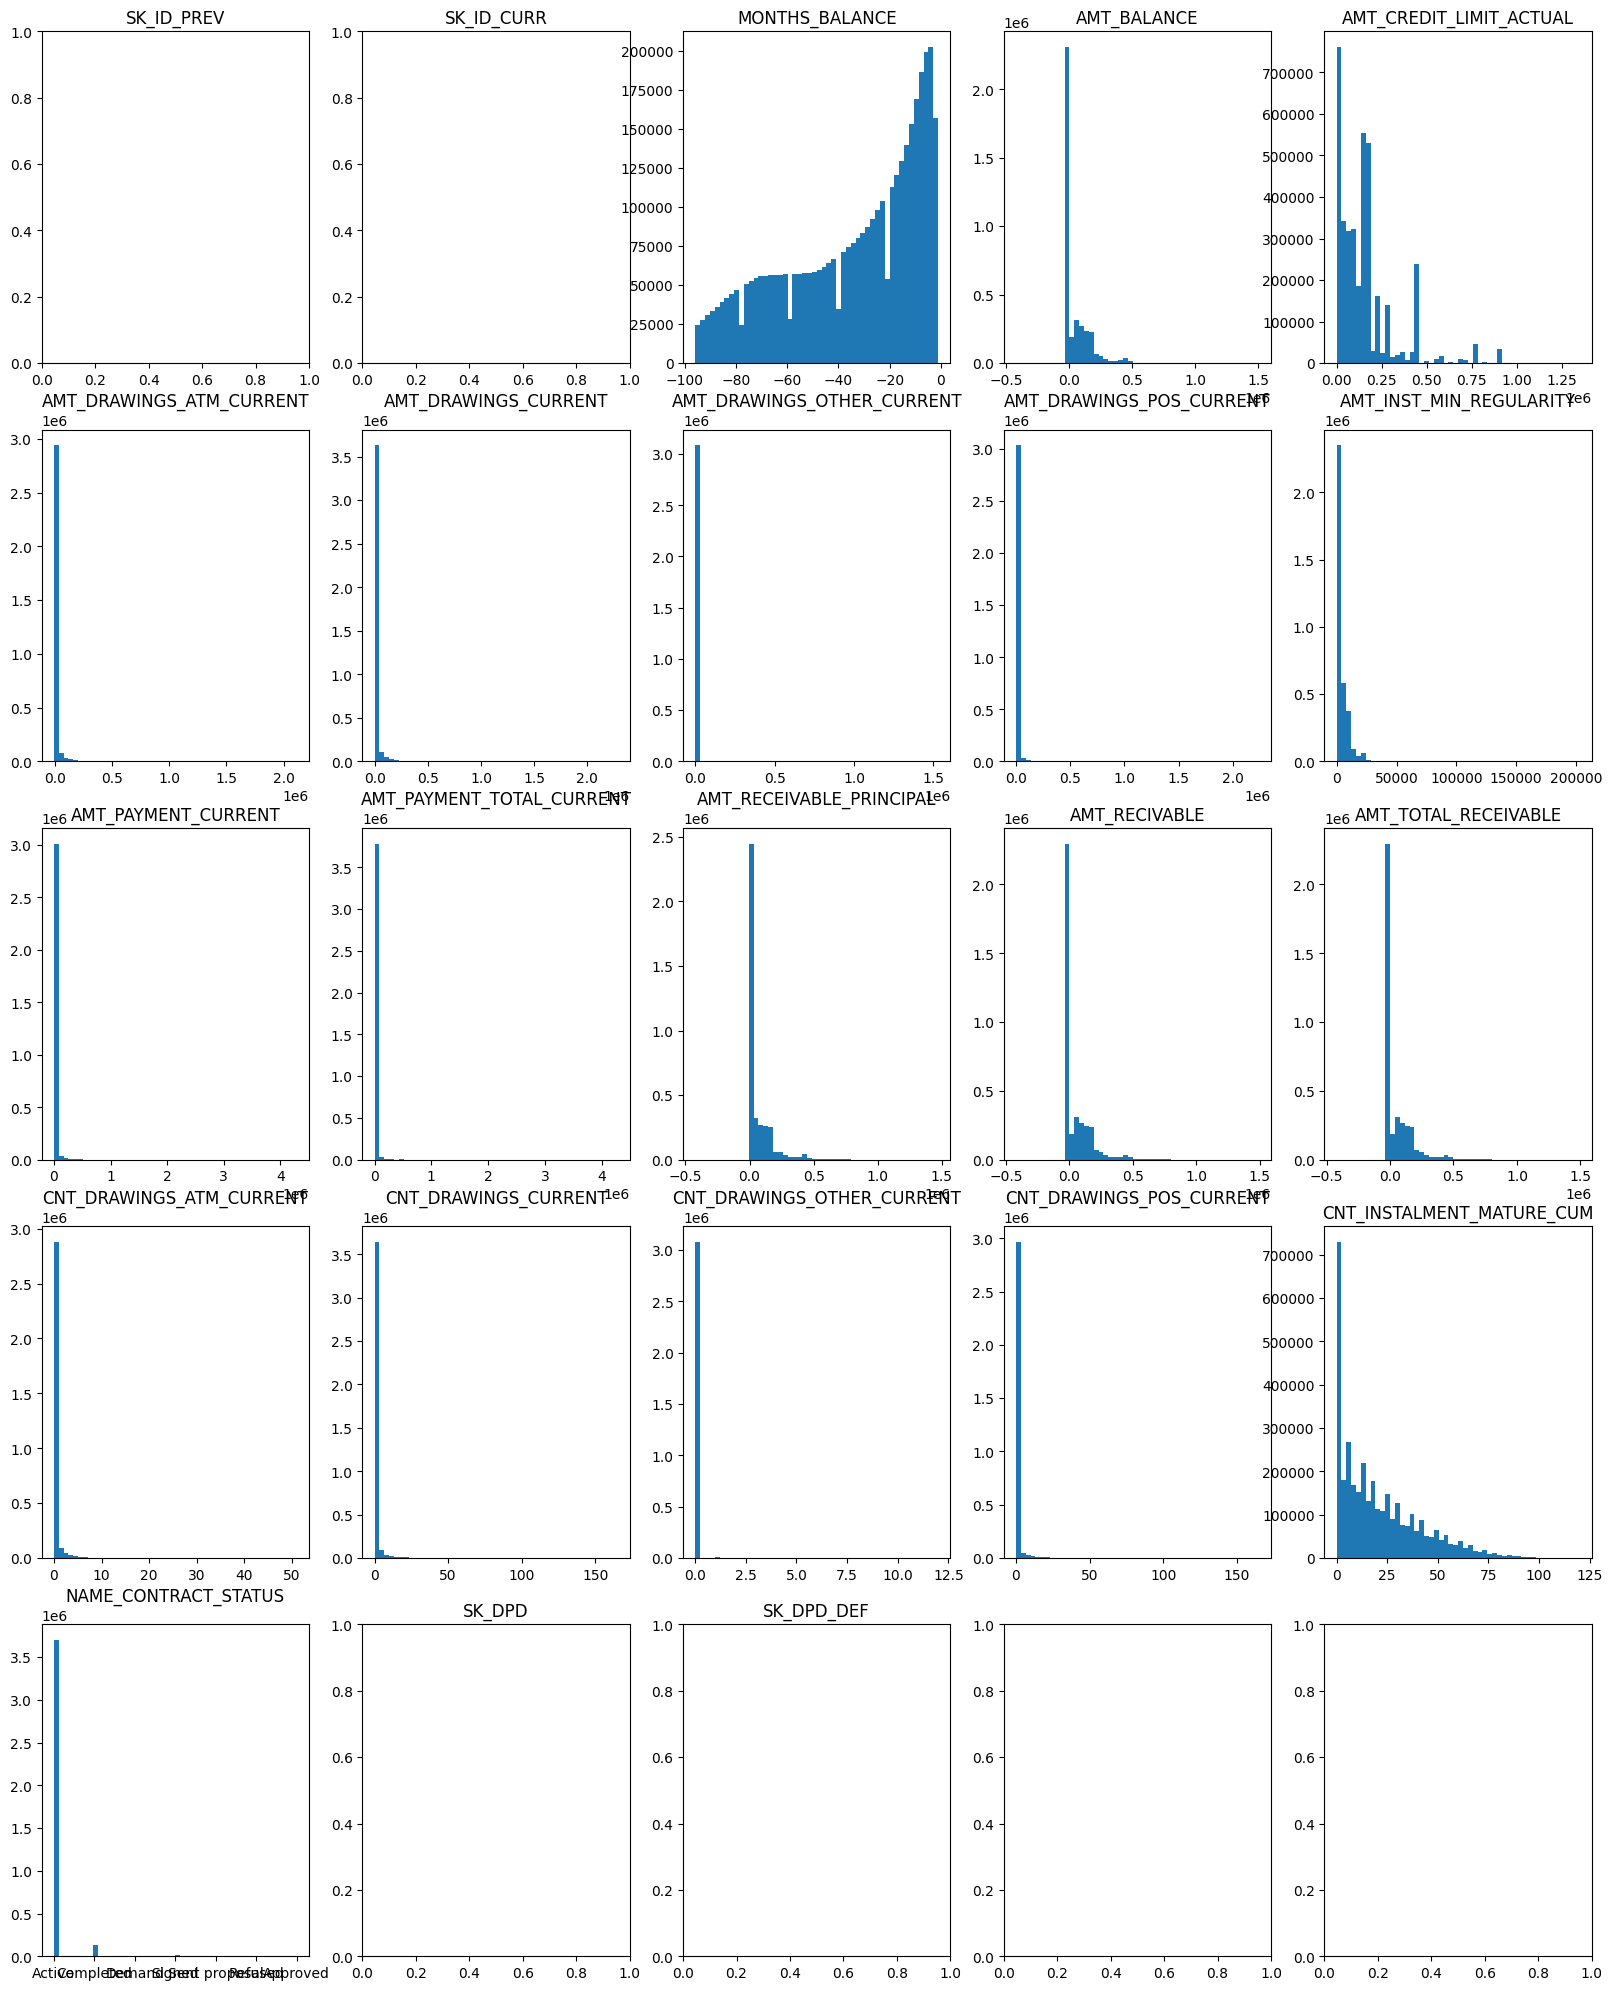

Fichier:  bureau


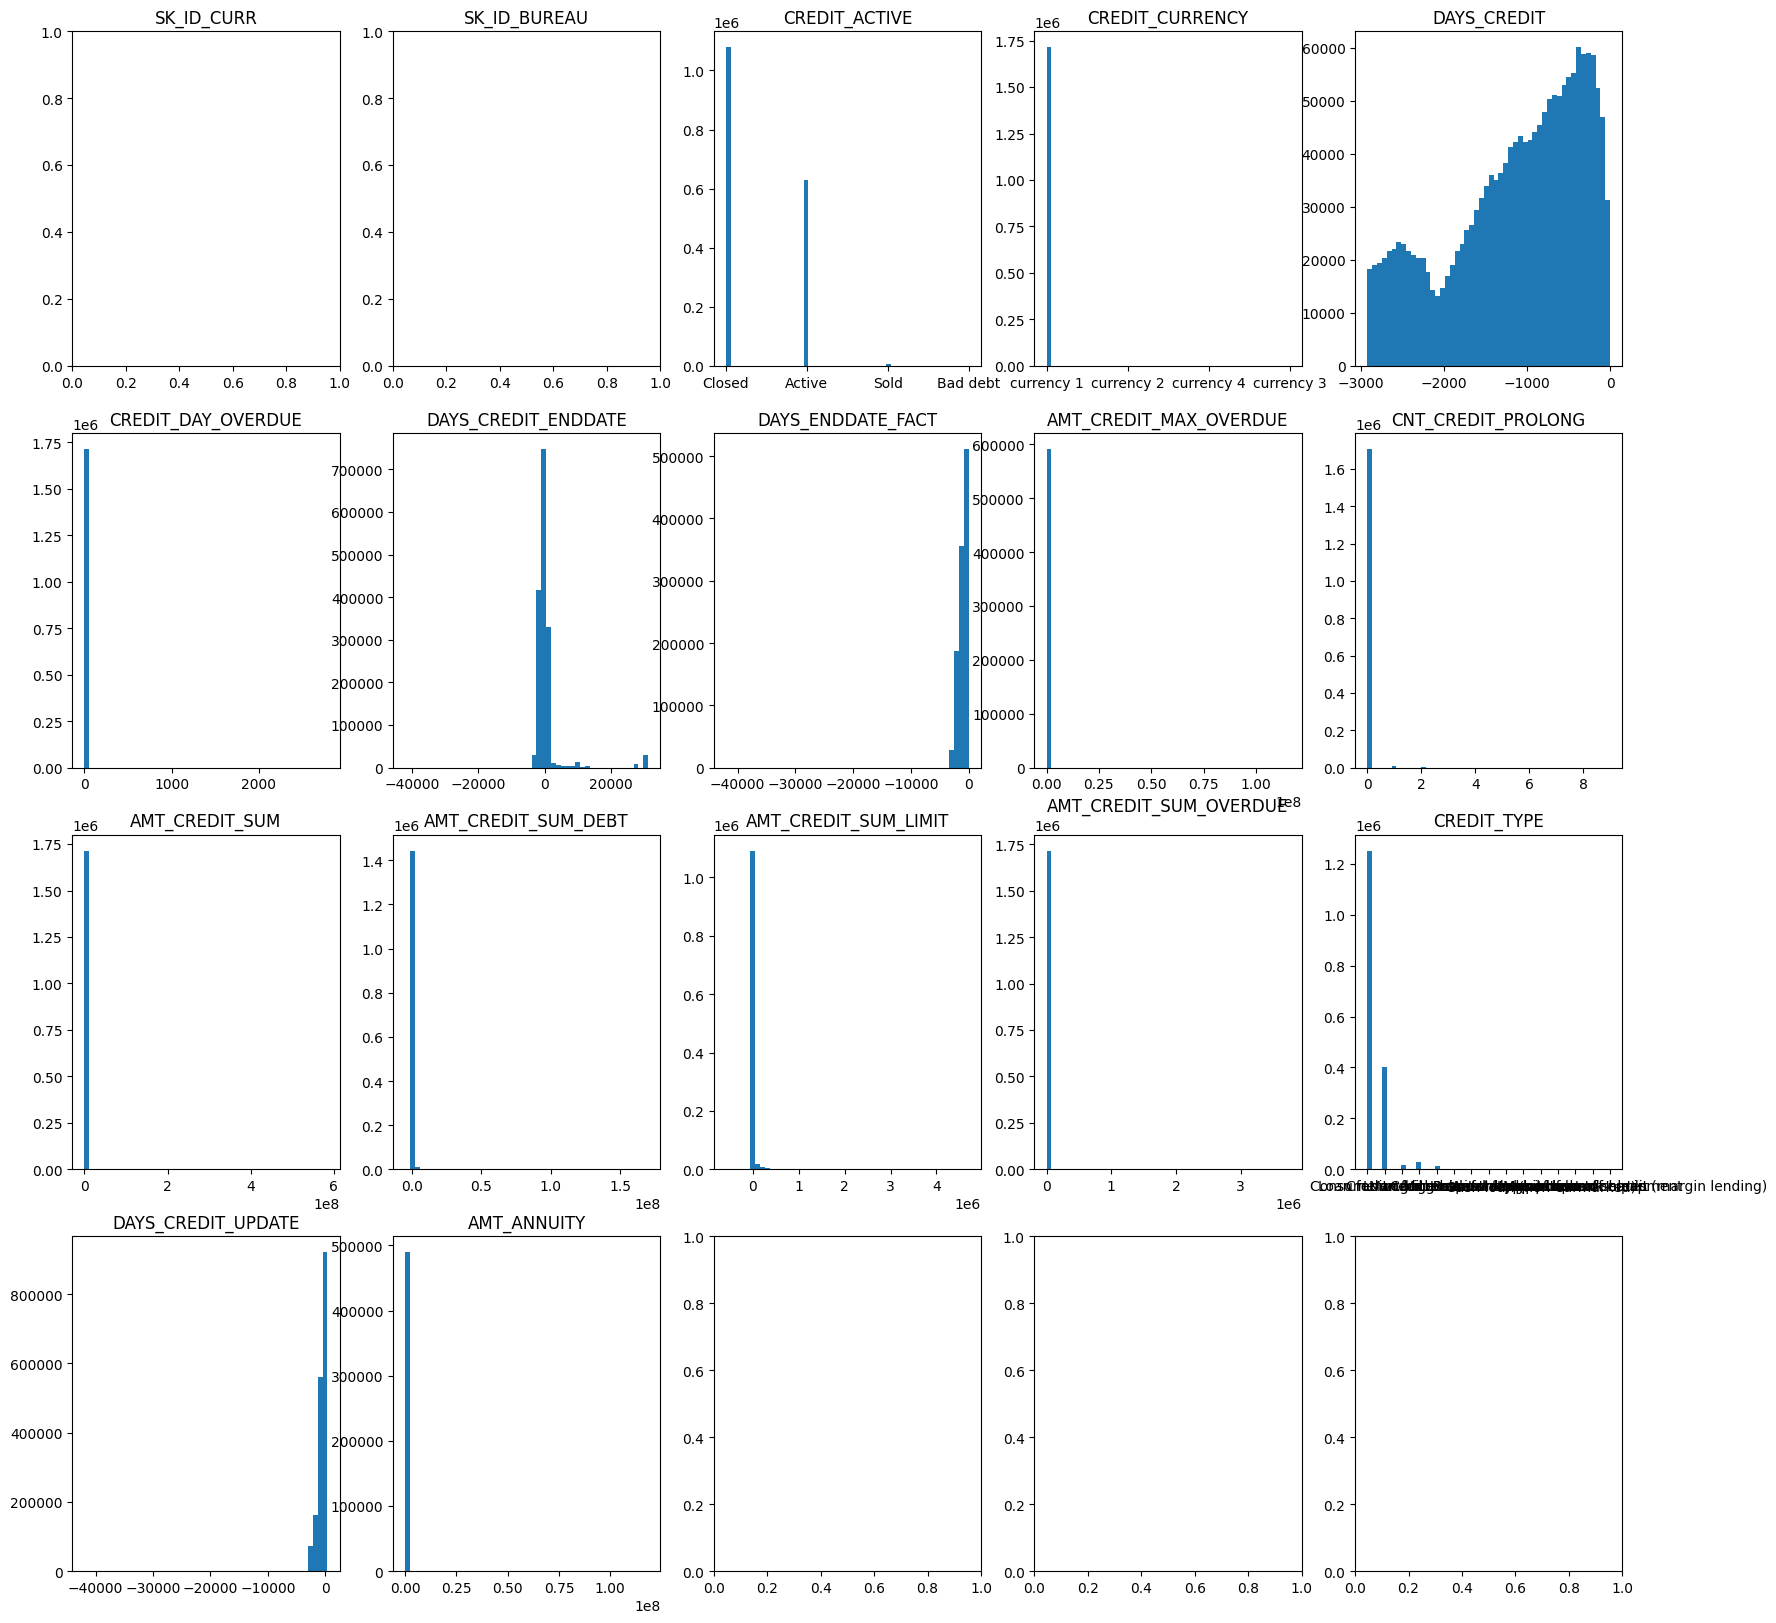

Fichier:  previous_application


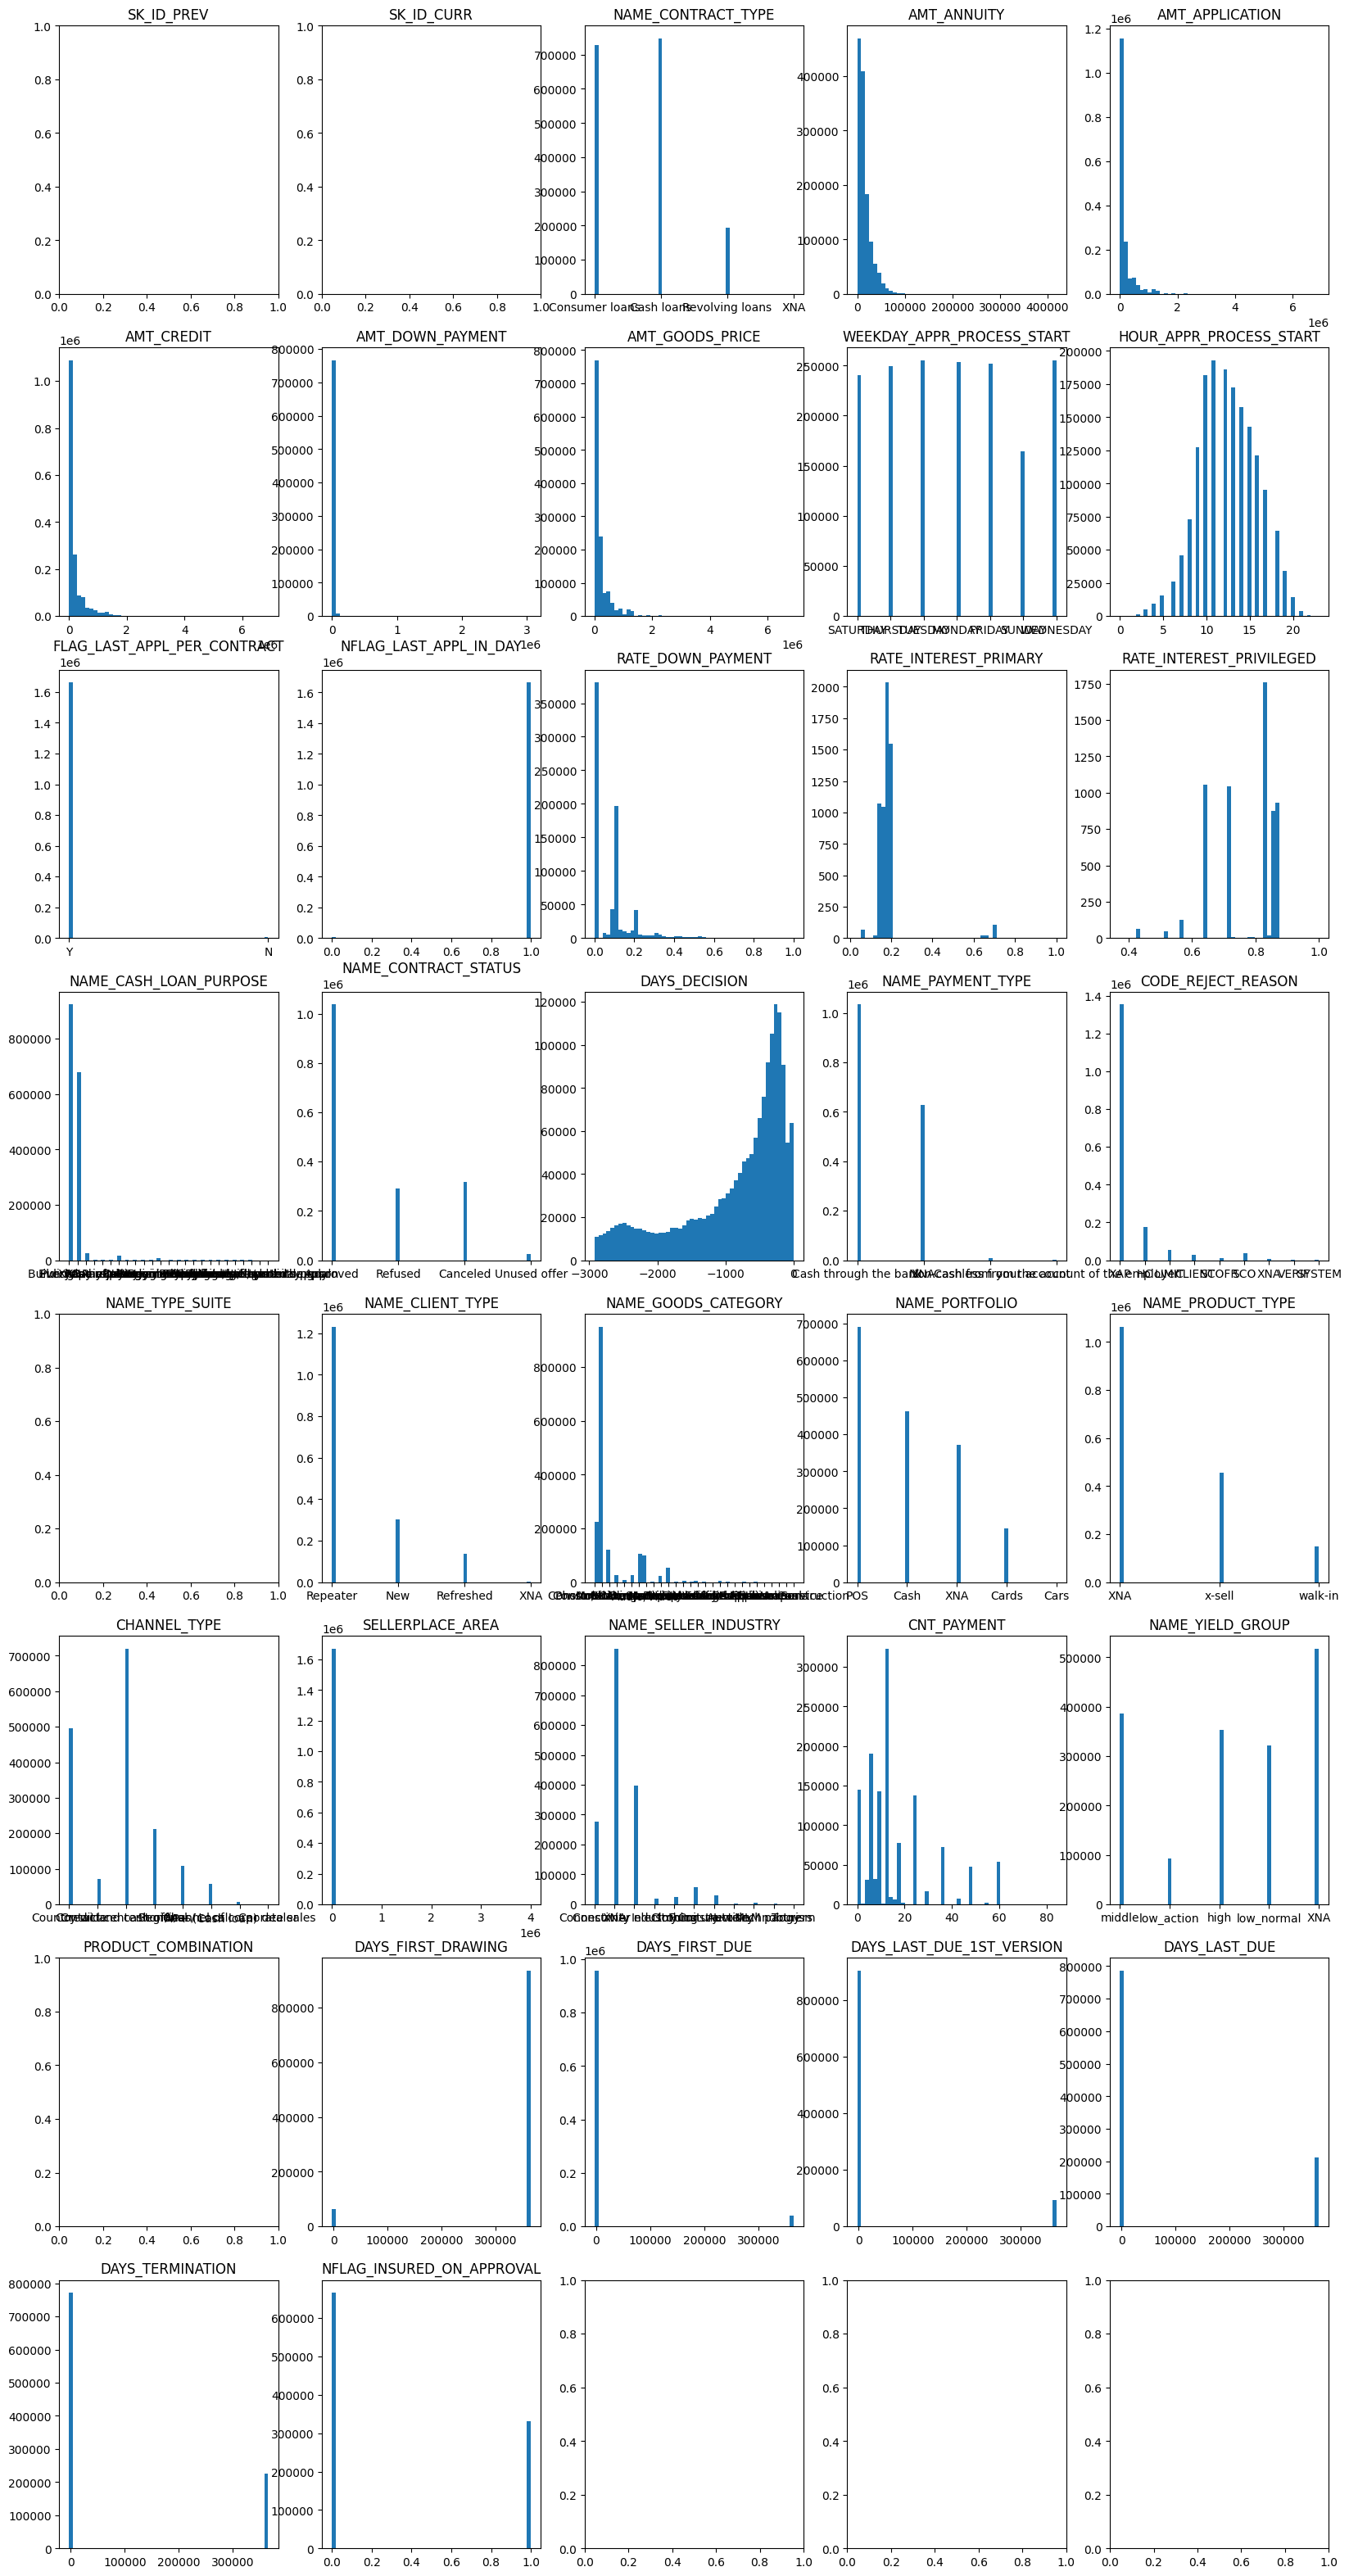

Fichier:  application_train


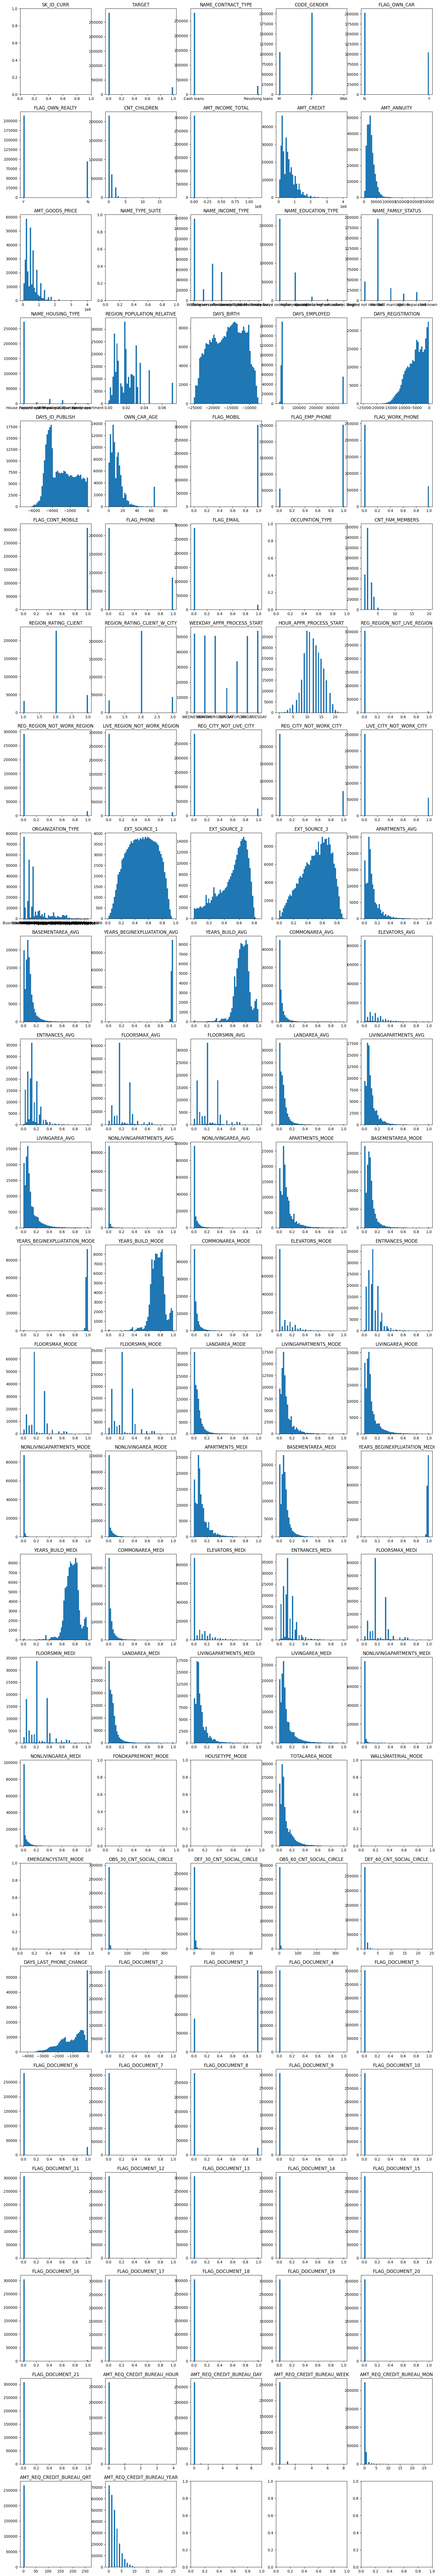

Fichier:  installments_payments


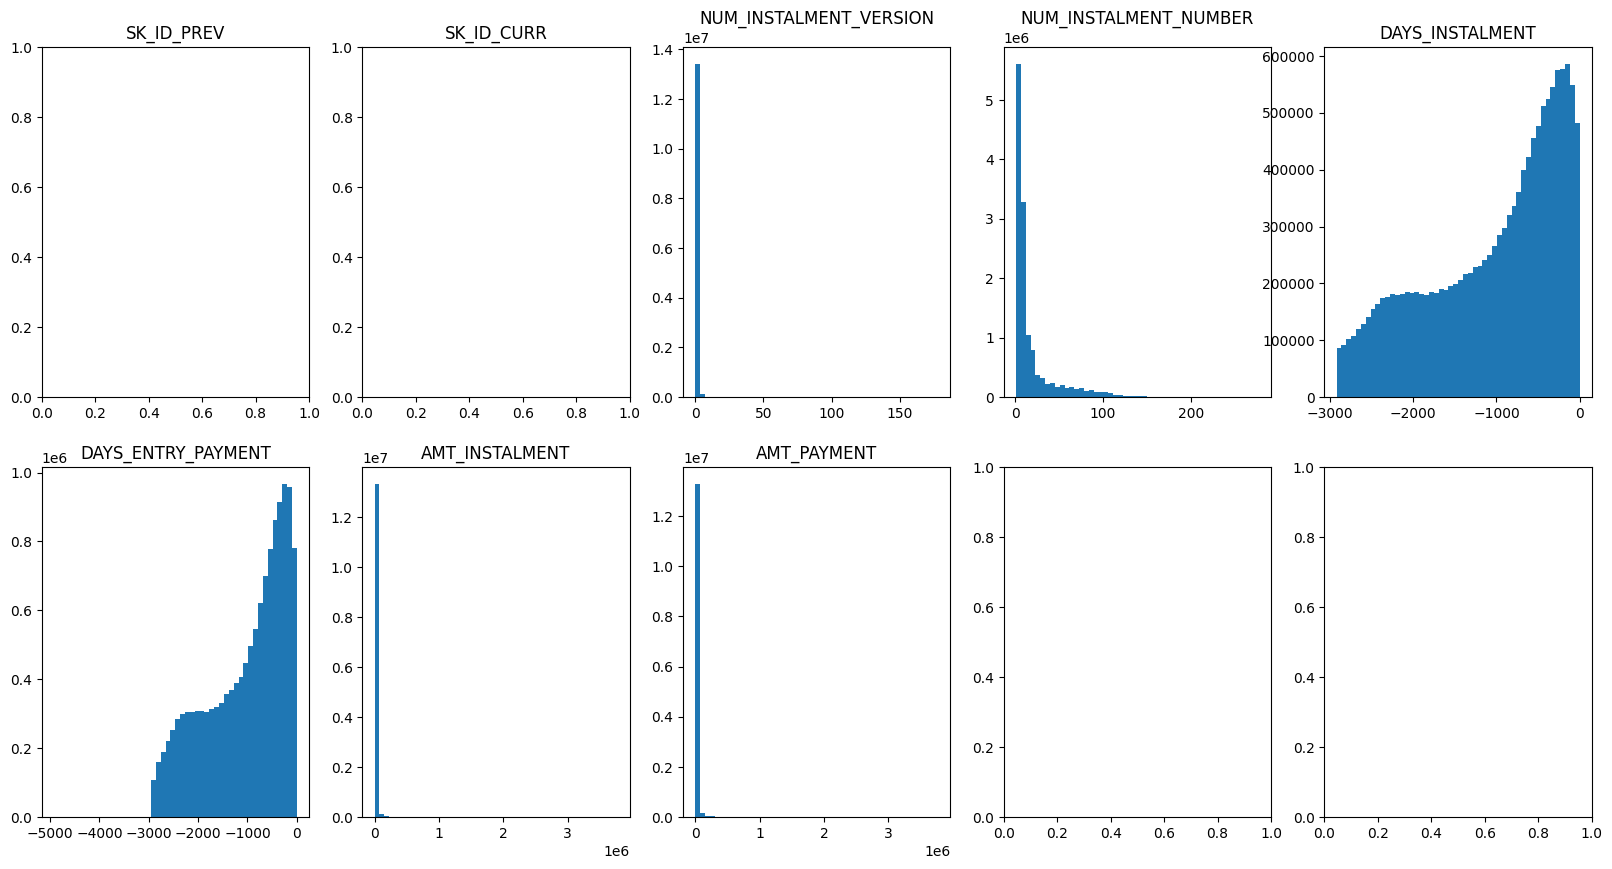

Fichier:  POS_CASH_balance


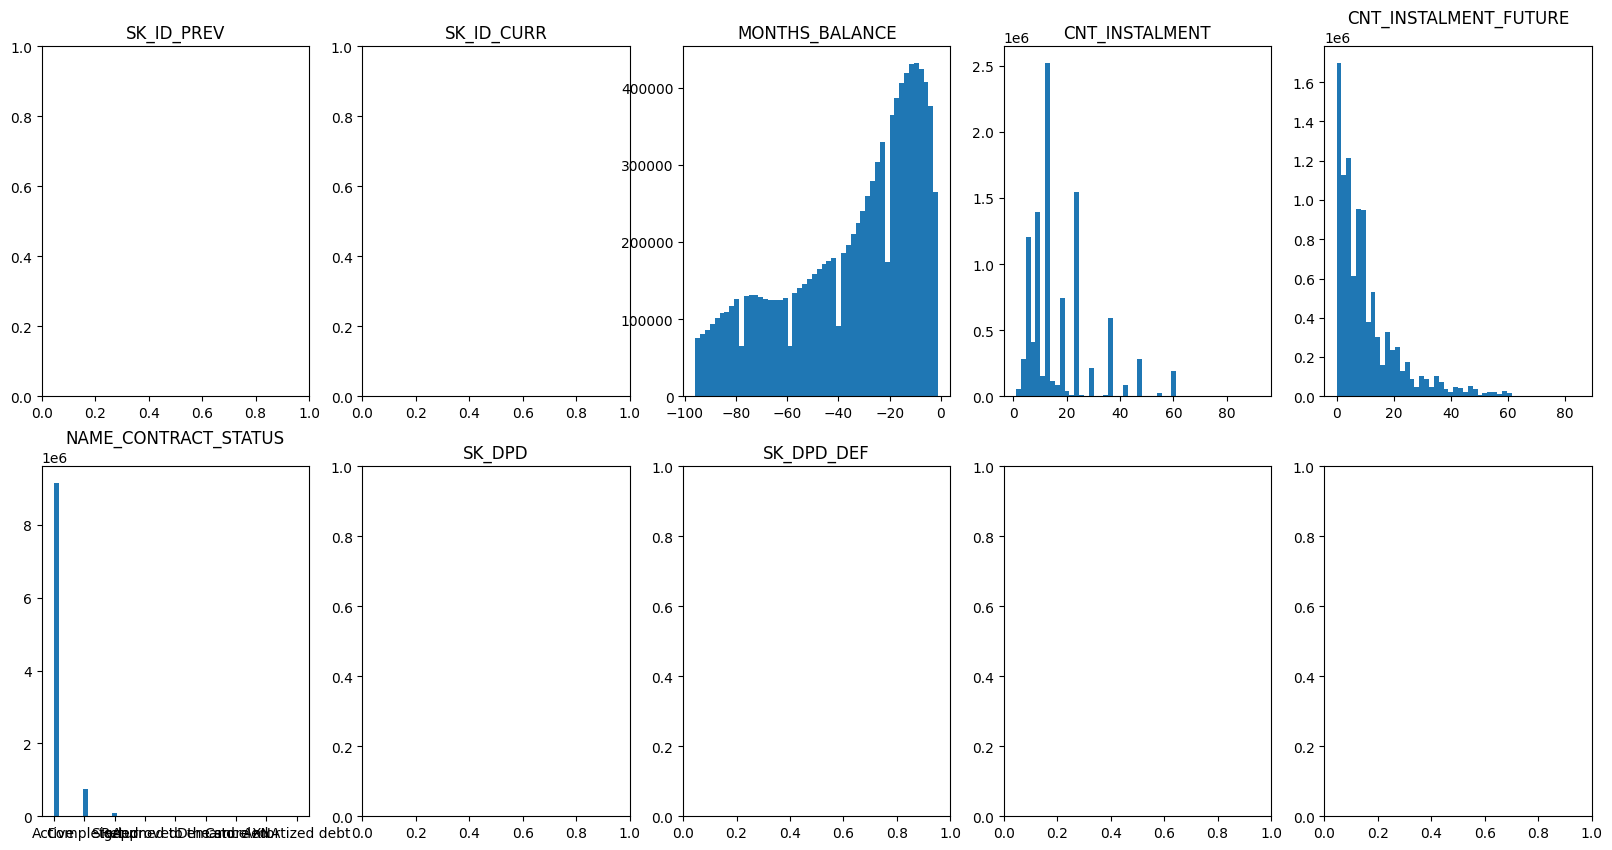

In [3]:
# Visualisation de la distribution des variables
column_index = ['SK_ID_BUREAU', 'SK_ID_PREV', 'SK_ID_CURR', 'SK_DPD', 'SK_DPD_DEF']

def view_histogram(df_brut, column_index):
    """ View histogram """
    for df_name, df_data in df_brut.items():

        nb_column = df_data.shape[1]
        nb_graph_y = 5
        nb_graph_x = int(nb_column / nb_graph_y) + 1
        

        fig, axs = plt.subplots(nb_graph_x, nb_graph_y, figsize=(20, nb_graph_x * 5))
        axs = axs.ravel()
        
        for i, column in enumerate(df_data.columns):
            axs[i].set_title(column)
            if column in column_index:
                continue
                
            try:    
                axs[i].hist(df_data[column], bins=50)
            except:
                continue
        print('Fichier: ', df_name)
        plt.show()
        

view_histogram(df_brut, column_index)

### Analyse de la variable cible

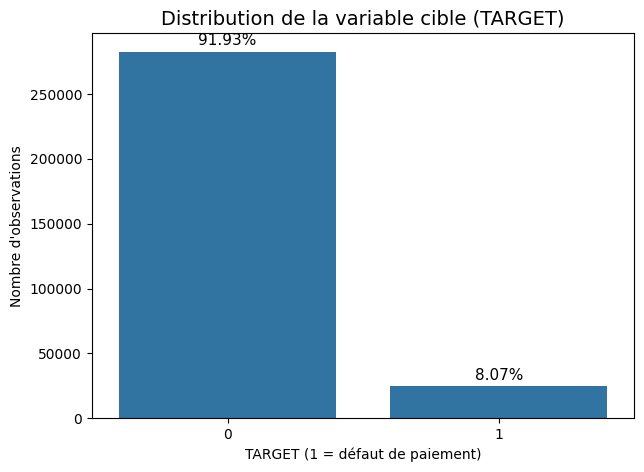

Répartition de la cible :
TARGET
0    91.93 %
1     8.07 %
Name: proportion, dtype: object


In [4]:

plt.figure(figsize=(7, 5))
df_train = df_brut['application_train']

sns.countplot(data=df_train, x='TARGET')
plt.title('Distribution de la variable cible (TARGET)', fontsize=14)
plt.xlabel('TARGET (1 = défaut de paiement)')
plt.ylabel('Nombre d\'observations')

total = len(df_train)
for p in plt.gca().patches:
    percentage = f'{100 * p.get_height() / total:.2f}%'
    plt.gca().annotate(percentage, (p.get_x() + p.get_width() / 2., p.get_height()),
                       ha='center', va='center', fontsize=11, xytext=(0, 8),
                       textcoords='offset points')

plt.show()

print("Répartition de la cible :")
print(df_train['TARGET'].value_counts(normalize=True)
      .mul(100)
      .round(2)
      .astype(str) + " %")


### Prétraitement des données

- ajout des features
- modification et adaptation des données

La partie preprocess est isolé dans un containeur Conda pour assurer la reproductibilité des données.

Elle est disponible dans le fichier src/data/preprocess.py

Elle sauvegarde le dataframe obtenue dans un fichier (parquet) dans le repertoire data/preprocessed


In [4]:
# répertoire de l'entrée MLproject
cwd = Path.cwd()
init_mlflow_dir = str(cwd.parent.resolve()) + "/src/data"

describe_column = pd.read_csv(DATA_DIR + "/describe_column.csv")

display(describe_column)


,name,table,dtype,origin,key,level,nb_row,unique,notnull,isna,...,std,min,25%,50%,75%,max,categ,categ_value,p_value,correlation
0,SK_ID_BUREAU,bureau_balance.csv,int64,original,FOREIGN,0,27299925,817395,27299925,0,...,492348.856904,5001709.0,5730933.0,6070821.0,6431951.00,6842888.0,KEY,_,0.0000,0.0000
1,MONTHS_BALANCE,bureau_balance.csv,int64,original,_,0,27299925,97,27299925,0,...,23.864509,-96.0,-46.0,-25.0,-11.00,0.0,NUMERIC,_,0.0000,0.0000
2,STATUS,bureau_balance.csv,object,original,_,0,27299925,8,27299925,0,...,NaN,NaN,NaN,NaN,NaN,NaN,CATEGORICAL,_,0.0000,0.0000
3,SK_ID_PREV,credit_card_balance.csv,int64,original,FOREIGN,2,3840312,104307,3840312,0,...,536469.470563,1000018.0,1434385.0,1897122.0,2369327.75,2843496.0,KEY,_,0.0000,0.0000
4,SK_ID_CURR,credit_card_balance.csv,int64,original,FOREIGN,2,3840312,103558,3840312,0,...,102704.475133,100006.0,189517.0,278396.0,367580.00,456250.0,KEY,_,0.0000,0.0000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
213,CNT_INSTALMENT,POS_CASH_balance.csv,float64,original,_,2,10001358,73,9975287,26071,...,11.995056,1.0,10.0,12.0,24.00,92.0,NUMERIC,_,0.0000,0.0185
214,CNT_INSTALMENT_FUTURE,POS_CASH_balance.csv,float64,original,_,2,10001358,79,9975271,26087,...,11.109058,0.0,3.0,7.0,14.00,85.0,NUMERIC,_,0.0000,0.0220
215,NAME_CONTRACT_STATUS,POS_CASH_balance.csv,object,original,_,2,10001358,9,10001358,0,...,NaN,NaN,NaN,NaN,NaN,NaN,CATEGORICAL,Amortized debt,0.0001,0.0067
216,SK_DPD,POS_CASH_balance.csv,int64,original,_,2,10001358,3400,10001358,0,...,132.714043,0.0,0.0,0.0,0.00,4231.0,KEY,_,0.0000,0.0000


In [16]:
describe_column_sorted = describe_column.reindex(
    describe_column["correlation"].abs().sort_values(ascending=False).index
)


display(describe_column_sorted[["name", "table", "categ", "correlation", "categ_value"]].head(30))




,name,table,categ,correlation,categ_value
123,EXT_SOURCE_3,application_train.csv,NUMERIC,-0.1789,_
122,EXT_SOURCE_2,application_train.csv,NUMERIC,-0.1605,_
121,EXT_SOURCE_1,application_train.csv,NUMERIC,-0.1553,_
97,DAYS_BIRTH,application_train.csv,NUMERIC,0.0782,_
30,DAYS_CREDIT,bureau.csv,NUMERIC,0.0616,_
92,NAME_INCOME_TYPE,application_train.csv,CATEGORICAL,0.0575,Working
93,NAME_EDUCATION_TYPE,application_train.csv,CATEGORICAL,-0.0566,Higher education
175,DAYS_LAST_PHONE_CHANGE,application_train.csv,NUMERIC,0.0552,_
83,CODE_GENDER,application_train.csv,CATEGORICAL,0.0547,M
59,NAME_CONTRACT_STATUS,previous_application.csv,CATEGORICAL,0.0545,Refused


In [7]:
describe_column_sorted = describe_column.reindex(
    describe_column["p_value"].sort_values(ascending=False).index
)


print(describe_column_sorted[["name", "table", "p_value"]].head(20))

                            name                  table  p_value
194             FLAG_DOCUMENT_20  application_train.csv   1.0000
102                   FLAG_MOBIL  application_train.csv   1.0000
186             FLAG_DOCUMENT_12  application_train.csv   1.0000
184             FLAG_DOCUMENT_10  application_train.csv   0.9280
105             FLAG_CONT_MOBILE  application_train.csv   0.8977
179              FLAG_DOCUMENT_5  application_train.csv   0.8824
181              FLAG_DOCUMENT_7  application_train.csv   0.5461
193             FLAG_DOCUMENT_19  application_train.csv   0.5372
107                   FLAG_EMAIL  application_train.csv   0.3367
178              FLAG_DOCUMENT_4  application_train.csv   0.2650
116  LIVE_REGION_NOT_WORK_REGION  application_train.csv   0.1219
191             FLAG_DOCUMENT_17  application_train.csv   0.0949
195             FLAG_DOCUMENT_21  application_train.csv   0.0607
185             FLAG_DOCUMENT_11  application_train.csv   0.0219
183              FLAG_DOC

In [18]:
df = df_brut['application_train']
col = "ORGANIZATION_TYPE"
target = "TARGET"

dummies = pd.get_dummies(df[col], drop_first=False)



corr_with_target = dummies.corrwith(df[target])
display(corr_with_target)

max_corr_value = corr_with_target.abs().idxmax()
max_corr = corr_with_target.loc[max_corr_value]

print("Modalité la plus corrélée :", max_corr_value)
print("Corrélation :", max_corr)



Advertising               0.000117
Agriculture               0.007901
Bank                     -0.009609
Business Entity Type 1    0.000339
Business Entity Type 2    0.003152
Business Entity Type 3    0.023993
Cleaning                  0.003290
Construction              0.019792
Culture                  -0.003265
Electricity              -0.002945
Emergency                -0.001458
Government               -0.007520
Hotel                    -0.003410
Housing                  -0.000464
Industry: type 1          0.006402
Industry: type 10        -0.001141
Industry: type 11         0.002009
Industry: type 12        -0.005444
Industry: type 13         0.002905
Industry: type 2         -0.001230
Industry: type 3          0.009691
Industry: type 4          0.004074
Industry: type 5         -0.001992
Industry: type 6         -0.000652
Industry: type 7         -0.000094
Industry: type 8          0.001436
Industry: type 9         -0.005379
Insurance                -0.003850
Kindergarten        

Modalité la plus corrélée : XNA
Corrélation : -0.04598707841557871


In [15]:
# Vérification
output_file = DATA_DIR + "/processed/application_train_processed.parquet"
df_prepossessed = pd.read_parquet(output_file)

print(df_prepossessed.head())

   SK_ID_CURR  TARGET NAME_CONTRACT_TYPE CODE_GENDER FLAG_OWN_CAR  \
0      100002       1         Cash loans           M            N   
1      100003       0         Cash loans           F            N   
2      100004       0    Revolving loans           M            Y   
3      100006       0         Cash loans           F            N   
4      100007       0         Cash loans           M            N   

  FLAG_OWN_REALTY  CNT_CHILDREN  AMT_INCOME_TOTAL  AMT_CREDIT  AMT_ANNUITY  \
0               Y             0          202500.0    406597.5      24700.5   
1               N             0          270000.0   1293502.5      35698.5   
2               Y             0           67500.0    135000.0       6750.0   
3               Y             0          135000.0    312682.5      29686.5   
4               Y             0          121500.0    513000.0      21865.5   

   ...  FLAG_DOCUMENT_18 FLAG_DOCUMENT_19 FLAG_DOCUMENT_20 FLAG_DOCUMENT_21  \
0  ...                 0             